<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/03_modelling_PHM18_etching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import os
import glob

In [4]:
df_all_1pct = pd.read_csv('/content/drive/MyDrive/phm18/df_all_sampled_1pct.csv')

print("행, 렬:", df_all_1pct.shape)
print("열 항목:", df_all_1pct.columns.tolist())

행, 렬: (824313, 27)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [6]:
threshold = 1839644

df_all_1pct['label_pressure_high'] = ( df_all_1pct['TTF_pressure_high'] <= threshold ).astype(int)
print( df_all_1pct['label_pressure_high'].value_counts() )

label_pressure_high
0    628956
1    195357
Name: count, dtype: int64


In [7]:
sensor_cols = [
    'IONGAUGEPRESSURE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLPRESSURE',
    'ACTUALROTATIONANGLE', 'ACTUALSTEPDURATION'
]

control_cols = [
    'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE',
    'FLOWCOOLFLOWRATE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK',
    'FIXTURETILTANGLE', 'ROTATIONSPEED', 'FIXTURESHUTTERPOSITION',
    'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER'
]

ttf_cols = [
    'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak'
]

In [9]:
train_cols = sensor_cols + control_cols

X = df_all_1pct[train_cols]
y = df_all_1pct['label_pressure_high']
print("X의 형태:", X.shape)
print("y의 형태:", y.shape)

X의 형태: (824313, 17)
y의 형태: (824313,)


In [10]:
# train/test 데이터 분리

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train의 형태:", X_train.shape)
print("X_test의 형태:", X_test.shape)
print("y_train의 형태:", y_train.shape)
print("y_test의 형태:", y_test.shape)

X_train의 형태: (659450, 17)
X_test의 형태: (164863, 17)
y_train의 형태: (659450,)
y_test의 형태: (164863,)


In [12]:
# Random Forest 모델 학습

from sklearn.ensemble import RandomForestClassifier

model_1pct = RandomForestClassifier(n_estimators=100, random_state=42)
model_1pct.fit(X_train, y_train)

print("학습 완료!")

학습 완료!


In [19]:
# 모델 성능 평가

from sklearn.metrics import classification_report

y_pred = model_1pct.predict(X_test) # 모델이 테스트 데이터를 보고 0과 1을 예측
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    125749
           1       0.99      0.99      0.99     39114

    accuracy                           1.00    164863
   macro avg       1.00      0.99      0.99    164863
weighted avg       1.00      1.00      1.00    164863



In [14]:
# 데이터 누수 가능성 파악
print(train_cols)

['IONGAUGEPRESSURE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLPRESSURE', 'ACTUALROTATIONANGLE', 'ACTUALSTEPDURATION', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'FLOWCOOLFLOWRATE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER']


In [16]:
import matplotlib.pyplot as plt

importances = model_1pct.feature_importances_
feature_importance_df = pd.DataFrame( {
    'feature': train_cols,
    'importance': importances
}).sort_values( 'importance', ascending=False ) # 오름차순

print( feature_importance_df )

                    feature  importance
15       ETCHAUXSOURCETIMER    0.162658
14          ETCHSOURCEUSAGE    0.118499
3       ACTUALROTATIONANGLE    0.116325
16      ETCHAUX2SOURCETIMER    0.111398
12            ROTATIONSPEED    0.077659
8          FLOWCOOLFLOWRATE    0.072592
2          FLOWCOOLPRESSURE    0.064345
1     ETCHSUPPRESSORCURRENT    0.044809
10       ETCHPBNGASREADBACK    0.042944
0          IONGAUGEPRESSURE    0.036101
5           ETCHBEAMVOLTAGE    0.033802
6           ETCHBEAMCURRENT    0.033311
9   ETCHGASCHANNEL1READBACK    0.031397
7     ETCHSUPPRESSORVOLTAGE    0.029788
11         FIXTURETILTANGLE    0.012589
4        ACTUALSTEPDURATION    0.010171
13   FIXTURESHUTTERPOSITION    0.001611


ACTUALROTATIONANGLE, EDA에서는 크게 주목하지 않았던 변수임. 모델이 통찰을 줌.

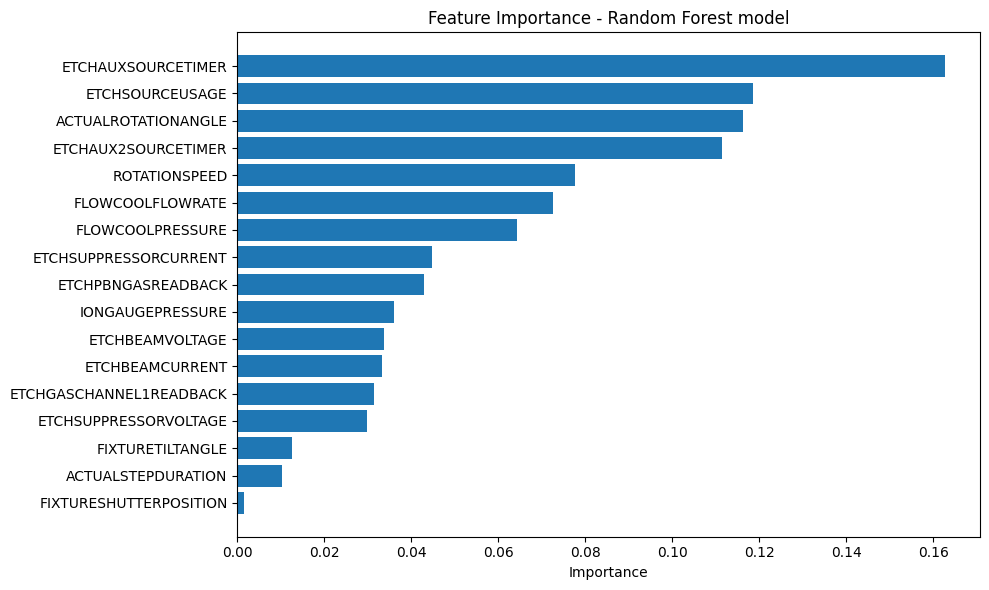

In [18]:
plt.figure(figsize=(10, 6))
plt.barh( feature_importance_df['feature'], feature_importance_df['importance'] )
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest model')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

EDA에서 핵심 변수로 추정한 변수들이, 랜덤 포레스트 feature importance에서도 동일하게 상위권으로 나왔다.

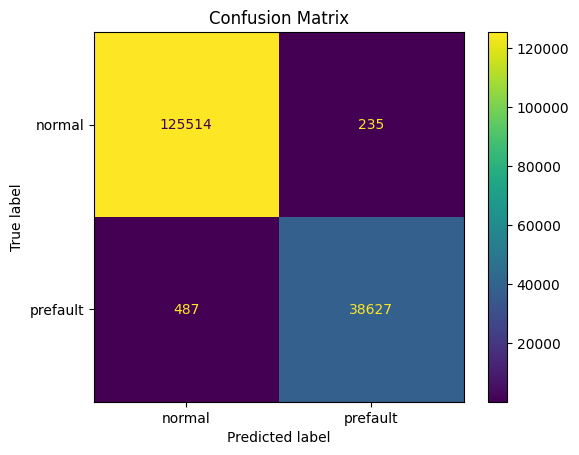

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred) # (실제 정답, 모델 예측)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'prefault'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()


487개의 위험 예측 → 고장인데 고장이 아니라고 보고